# EXPERIMENTATION


In [1]:
#imports
import pandas as pd
import numpy as np
import logging
from sklearn.base import BaseEstimator
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import mlflow.sklearn
import xgboost as xgb
import matplotlib.pyplot as plt

import mlflow
from contextlib import nullcontext

import os
import yaml
#logging
logging.basicConfig(level=logging.INFO)
logger=logging.getLogger()

#MLflow
mlflow_tracking_uri="http://localhost:5000"

In [2]:
#Load data
data_path="../data/processed/featured_house_data.csv"
data=pd.read_csv(data_path)

X=data.drop("price",axis=1)
y=data["price"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(data.shape)
print(X_train.shape)
print(X_test.shape)

(77, 16)
(61, 15)
(16, 15)


In [3]:
#Feature selection
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor

#Using XGBoost for RFE
xgb_model=XGBRegressor(objective="reg:squarederror")
xgb_model.fit(X_train,y_train)

#RFE
rfe_selector=RFE(xgb_model,n_features_to_select=10)
rfe_selector.fit(X_train,y_train)
rfe_selected_features=X.columns[rfe_selector.support_]
rfe_ignored_features=X.columns[~rfe_selector.support_]

print("Selected")
for i in rfe_selected_features:
    print(i)

print("Ignored")
for i in rfe_ignored_features:
    print(i)

#Store for config

selected_features_dict={
    "rfe":list(rfe_selected_features)
}

#Filter datasets to use the selected features
X_train=X_train[rfe_selected_features]
X_test=X_test[rfe_selected_features]

Selected
num__sqft
num__bathrooms
num__house_age
num__bed_bath_ratio
cat__location_Rural
cat__location_Urban
cat__condition_Excellent
cat__condition_Fair
cat__condition_Good
cat__condition_Poor
Ignored
num__bedrooms
cat__location_Downtown
cat__location_Mountain
cat__location_Suburb
cat__location_Waterfront


In [4]:
#Set up MLflow
if mlflow_tracking_uri:
    mlflow.set_tracking_uri(mlflow_tracking_uri)
    mlflow.set_experiment("MLOps project - House Price Prediction Experiment")

2026/02/18 20:14:13 INFO mlflow.tracking.fluent: Experiment with name 'MLOps project - House Price Prediction Experiment' does not exist. Creating a new experiment.


In [5]:
#Define models and hyperparameter grids
models = {
    "LinearRegression":LinearRegression(),
    "RandomForest":RandomForestRegressor(),
    "GradientBoosting":GradientBoostingRegressor(),
    "XGBoost":xgb.XGBRegressor(objective="reg:squarederror")
}

model_grids={
    "LinearRegression":{},
    "RandomForest":{
        "n_estimators":[100,150],
        "max_depth":[None,10,20]
    },
    "GradientBoosting":{
        "n_estimators":[100,250],
        "learning_rate":[0.1,0.05],
        "max_depth":[3,10]
    },
    "XGBoost":{
        "n_estimators":[100,150],
        "learning_rate":[0.1,0.05],
        "max_depth":[3,10]
    }
}

In [6]:
def evaluate_model_with_gridsearch(name,model,grid,X_train,y_train,X_test,y_test):
    if grid:
        clf=GridSearchCV(model,grid,cv=3,scoring="r2",n_jobs=-1)
        clf.fit(X_train,y_train)
        best_model=clf.best_estimator_
        best_params=clf.best_params_
    else:
        model.fit(X_train,y_train)
        best_model=model
        best_params=model.get_params()
    y_pred=best_model.predict(X_test)
    mae=mean_absolute_error(y_test,y_pred)
    mse=mean_squared_error(y_test,y_pred)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,y_pred)

    return {
        "mae":mae,
        "mse":mse,
        "rmse":rmse,
        "r2":r2,
        "model":best_model,
        "params":best_params
    }     

In [7]:
results={}
with mlflow.start_run(run_name="Model_comparison") if mlflow_tracking_uri else nullcontext():
    for name,model in models.items():
        logger.info(f"Training {name}...")
        with mlflow.start_run(run_name=name,nested=True) if mlflow_tracking_uri else nullcontext():
            evaluation=evaluate_model_with_gridsearch(name,model,model_grids[name],X_train,y_train,X_test,y_test)
            results[name]=evaluation

            if mlflow_tracking_uri:
                mlflow.log_params(evaluation["params"])
                mlflow.log_metrics({
                    "mae":evaluation["mae"],
                    "mse":evaluation["mse"],
                    "rmse":evaluation["rmse"],
                    "r2":evaluation["r2"],
                })
                mlflow.sklearn.log_model(evaluation["model"],name=name.lower().replace(" ","_"))
            print(f"{name} R2: {evaluation["r2"]} RMSE:{evaluation["rmse"]} MSE: {evaluation["mse"]} MAE: {evaluation["mae"]}")

INFO:root:Training LinearRegression...
c:\Users\Carlos\Desktop\Carlos U\MLOps\mlops-project\.venv\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)
2026/02/18 20:14:41 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
INFO:root:Training RandomForest...


LinearRegression R2: 0.9095563969767039 RMSE:64906.17963105234 MSE: 4212812154.2984343 MAE: 36862.72127282388
🏃 View run LinearRegression at: http://localhost:5000/#/experiments/3/runs/2503bddf896d4e889985a5c3eedbea4a
🧪 View experiment at: http://localhost:5000/#/experiments/3


c:\Users\Carlos\Desktop\Carlos U\MLOps\mlops-project\.venv\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)
2026/02/18 20:14:53 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
INFO:root:Training GradientBoosting...


RandomForest R2: 0.9536773512911725 RMSE:46450.86565788936 MSE: 2157682920.367285 MAE: 25502.124999999993
🏃 View run RandomForest at: http://localhost:5000/#/experiments/3/runs/8f279a836b2c4595b6170a8495694d94
🧪 View experiment at: http://localhost:5000/#/experiments/3


c:\Users\Carlos\Desktop\Carlos U\MLOps\mlops-project\.venv\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)
2026/02/18 20:14:58 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
INFO:root:Training XGBoost...


GradientBoosting R2: 0.932132869483014 RMSE:56224.663309087875 MSE: 3161212764.220292 MAE: 27264.309010239824
🏃 View run GradientBoosting at: http://localhost:5000/#/experiments/3/runs/d3a8625747414d41854e31dc35dbf3d0
🧪 View experiment at: http://localhost:5000/#/experiments/3


c:\Users\Carlos\Desktop\Carlos U\MLOps\mlops-project\.venv\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)
2026/02/18 20:15:05 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


XGBoost R2: 0.953978419303894 RMSE:46299.67637035922 MSE: 2143660032.0 MAE: 25129.013671875
🏃 View run XGBoost at: http://localhost:5000/#/experiments/3/runs/f9f9f07c87764cc2af8eead2e7540280
🧪 View experiment at: http://localhost:5000/#/experiments/3
🏃 View run Model_comparison at: http://localhost:5000/#/experiments/3/runs/85c00e752d50424ab721ca5373e6974a
🧪 View experiment at: http://localhost:5000/#/experiments/3


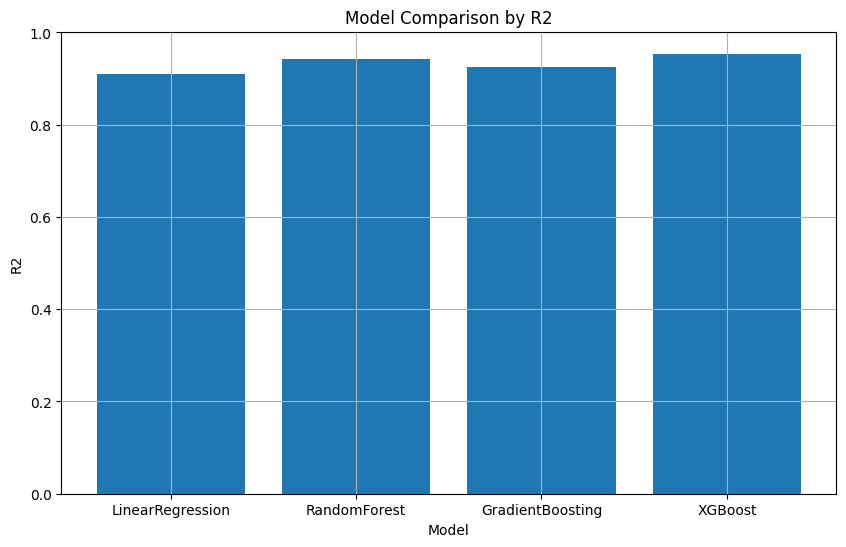

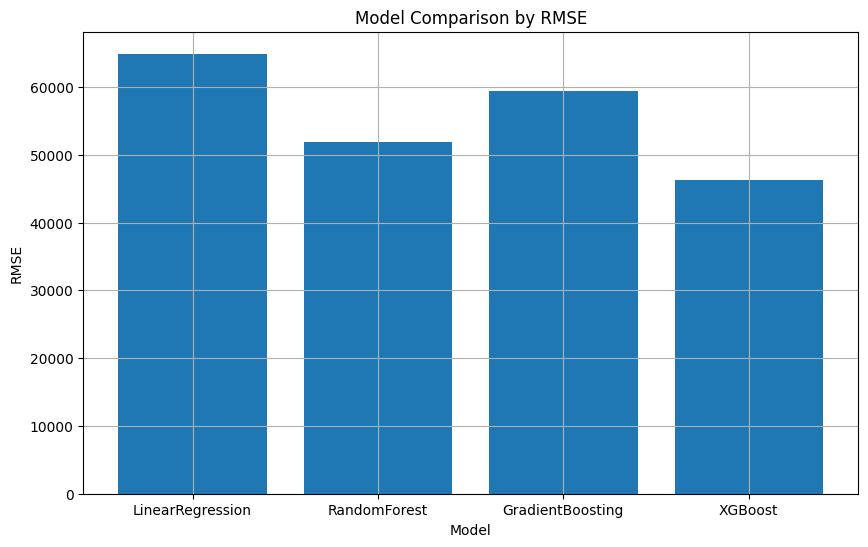

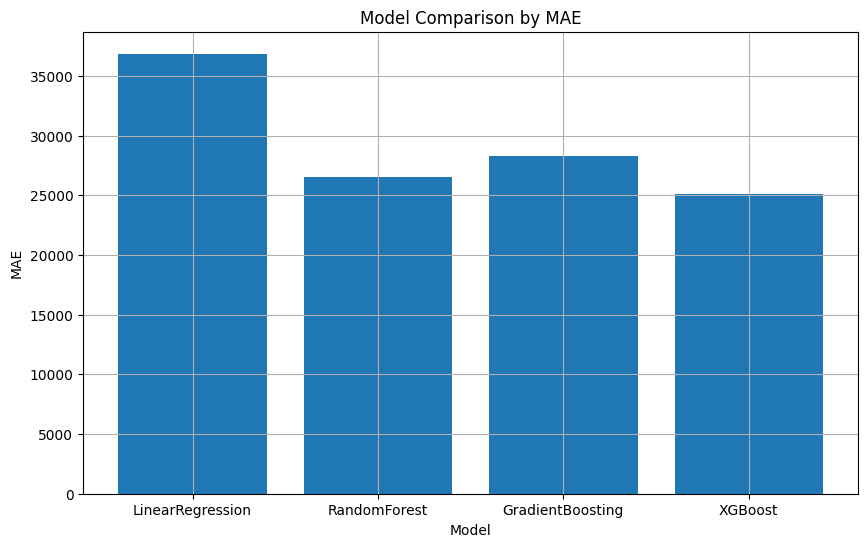

In [24]:
def plot_model_metrics(results, metric='r2'):
    names = list(results.keys())
    values = [results[name][metric] for name in names]

    plt.figure(figsize=(10, 6))
    plt.bar(names, values)
    plt.title(f'Model Comparison by {metric.upper()}')
    plt.xlabel('Model')
    plt.ylabel(metric.upper())
    plt.grid(True)
    plt.show()

# Example usage:
plot_model_metrics(results, metric='r2')
plot_model_metrics(results, metric='rmse')
plot_model_metrics(results, metric='mae')



In [8]:
#Save model with selected features
best_model_name=max(results,key=lambda x:results[x]["r2"])
best_model=results[best_model_name]["model"]
best_params=best_model.get_params()
best_r2=float(results[best_model_name]["r2"])
best_mae=float(results[best_model_name]["mae"])
best_rmse=float(results[best_model_name]["rmse"])

print(f" Best Model: {best_model_name}")
print(f" r2: {best_r2}")
print(f" MAE: {best_mae}")
print(f" RMSE: {best_rmse}")

model_config={
    "model":{
        "name":"house_price_model",
        "best_model":best_model_name,
        "parameters":best_params,
        "r2_score":best_r2,
        "mae":best_mae,
        "target_variable":"price",
        "feature_sets":selected_features_dict,
    }
}

config_path="../configs/model_config.yaml"
os.makedirs(os.path.dirname(config_path),exist_ok=True)
with open(config_path,"w") as f:
    yaml.dump(model_config,f)

print(f"Model saved to {config_path}")

 Best Model: XGBoost
 r2: 0.953978419303894
 MAE: 25129.013671875
 RMSE: 46299.67637035922
Model saved to ../configs/model_config.yaml


In [13]:
    #Load data
data=pd.read_csv("../data/processed/featured_house_data.csv")
target="price"
#Selecting features from training experimentation
# X=data.drop(columns=[target])

with open("../configs/model_config.yaml","r") as f:
    config = yaml.safe_load(f)
model_cfg=config["model"]

features_sets=model_cfg["feature_sets"]["rfe"]
print(features_sets)
print(data[features_sets])

['num__sqft', 'num__bathrooms', 'num__house_age', 'num__bed_bath_ratio', 'cat__location_Rural', 'cat__location_Urban', 'cat__condition_Excellent', 'cat__condition_Fair', 'cat__condition_Good', 'cat__condition_Poor']
    num__sqft  num__bathrooms  num__house_age  num__bed_bath_ratio  \
0      1527.0             1.5            70.0             1.333333   
1      2526.0             2.5            28.0             1.200000   
2      1622.0             1.5            51.0             1.333333   
3      3102.0             3.0            21.0             1.333333   
4      1835.0             2.0            44.0             1.000000   
..        ...             ...             ...                  ...   
72     2080.0             2.0            35.0             1.500000   
73     1640.0             1.5            63.0             1.333333   
74     2220.0             2.0            41.0             1.500000   
75     1730.0             1.5            61.0             1.333333   
76     3170.0 

In [ ]:
with open("../configs/model_config.yaml","r") as f:
    config = yaml.safe_load(f)
model_cfg=config["model"]

features_sets=model_cfg["feature_sets"]["rfe"]
print(features_sets)


['num__sqft', 'num__bathrooms', 'num__house_age', 'num__bed_bath_ratio', 'cat__location_Rural', 'cat__location_Urban', 'cat__condition_Excellent', 'cat__condition_Fair', 'cat__condition_Good', 'cat__condition_Poor']
